# Iris Flower Classification

<img src="https://storage.googleapis.com/kaggle-media/learn/images/RcxYYBA.png">

### Background

The Iris dataset contains measurements of three flower species: setosa, versicolor, and virginica. Each flower is described using features like sepal length, sepal width, petal length, and petal width. The task is to build a machine learning model that learns from this labeled data and predicts the correct species of an Iris flower based on its measurements.

### Objective 

In this experiment, the Iris dataset is used to create a classification model that predicts the species of an iris flower using features such as sepal length, sepal width, petal length, and petal width. This dataset is one of the most popular examples for understanding classification in machine learning.



In [1]:
# Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Iris.csv")

In [5]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,NaN,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
df.shape  #no of row, columns

(150, 6)

In [7]:
df.describe()   #statistical schenario of numerical coulmns

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,149.000000,150.000000,150.000000,150.000000
mean,75.500000,5.848322,3.054000,3.758667,1.198667
std,43.445368,0.828594,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.describe(include="O")

,Species
count,150
unique,3
top,Iris-setosa
freq,50


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  149 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
df.groupby('Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.004082,3.418,1.464,0.244
Iris-versicolor,75.5,5.936000,2.770,4.260,1.326
Iris-virginica,125.5,6.588000,2.974,5.552,2.026


## Data Visualization

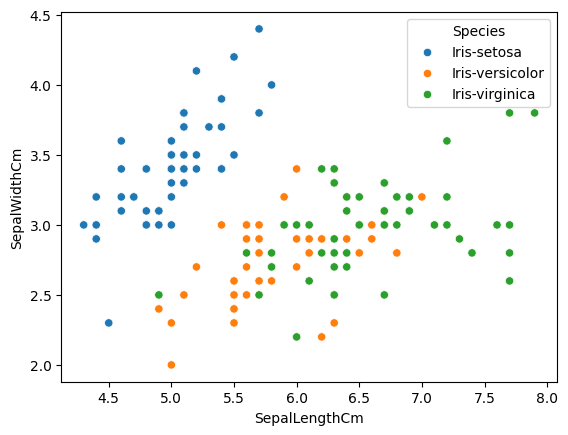

In [10]:
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df)
plt.show()

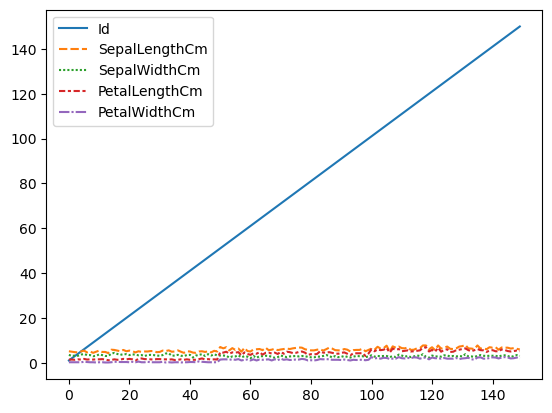

In [8]:
sns.lineplot(data=df.drop(['Species'], axis=1))
plt.show()

In [14]:
df1 = df.drop(["Id",'Species'], axis=1)
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.848322,3.5,1.4,0.2
1,4.900000,3.0,1.4,0.2
2,4.700000,3.2,1.3,0.2
3,4.600000,3.1,1.5,0.2
4,5.000000,3.6,1.4,0.2
...,...,...,...,...
145,6.700000,3.0,5.2,2.3
146,6.300000,2.5,5.0,1.9
147,6.500000,3.0,5.2,2.0
148,6.200000,3.4,5.4,2.3


In [13]:
df['SepalLengthCm'].fillna(df['SepalLengthCm'].mean(), inplace= True)

C:\Users\Chandrashekhar\AppData\Local\Temp\ipykernel_13920\3644148713.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SepalLengthCm'].fillna(df['SepalLengthCm'].mean(), inplace= True)


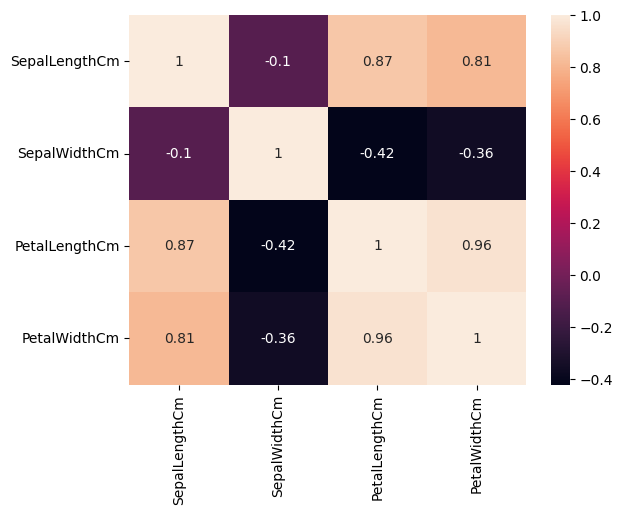

In [15]:
sns.heatmap(df1.corr(), annot=True)
plt.show()

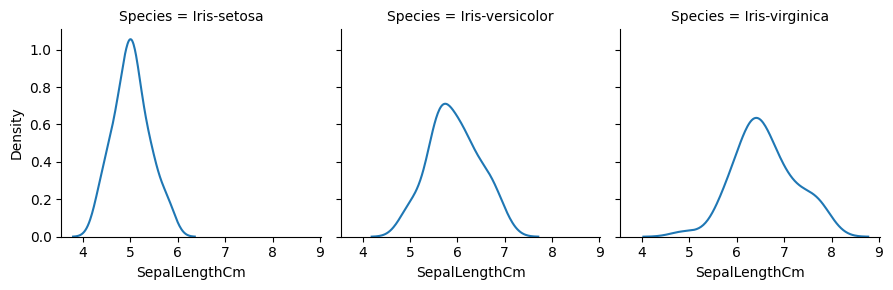

In [16]:
g = sns.FacetGrid(df, col='Species')
g = g.map(sns.kdeplot, 'SepalLengthCm')

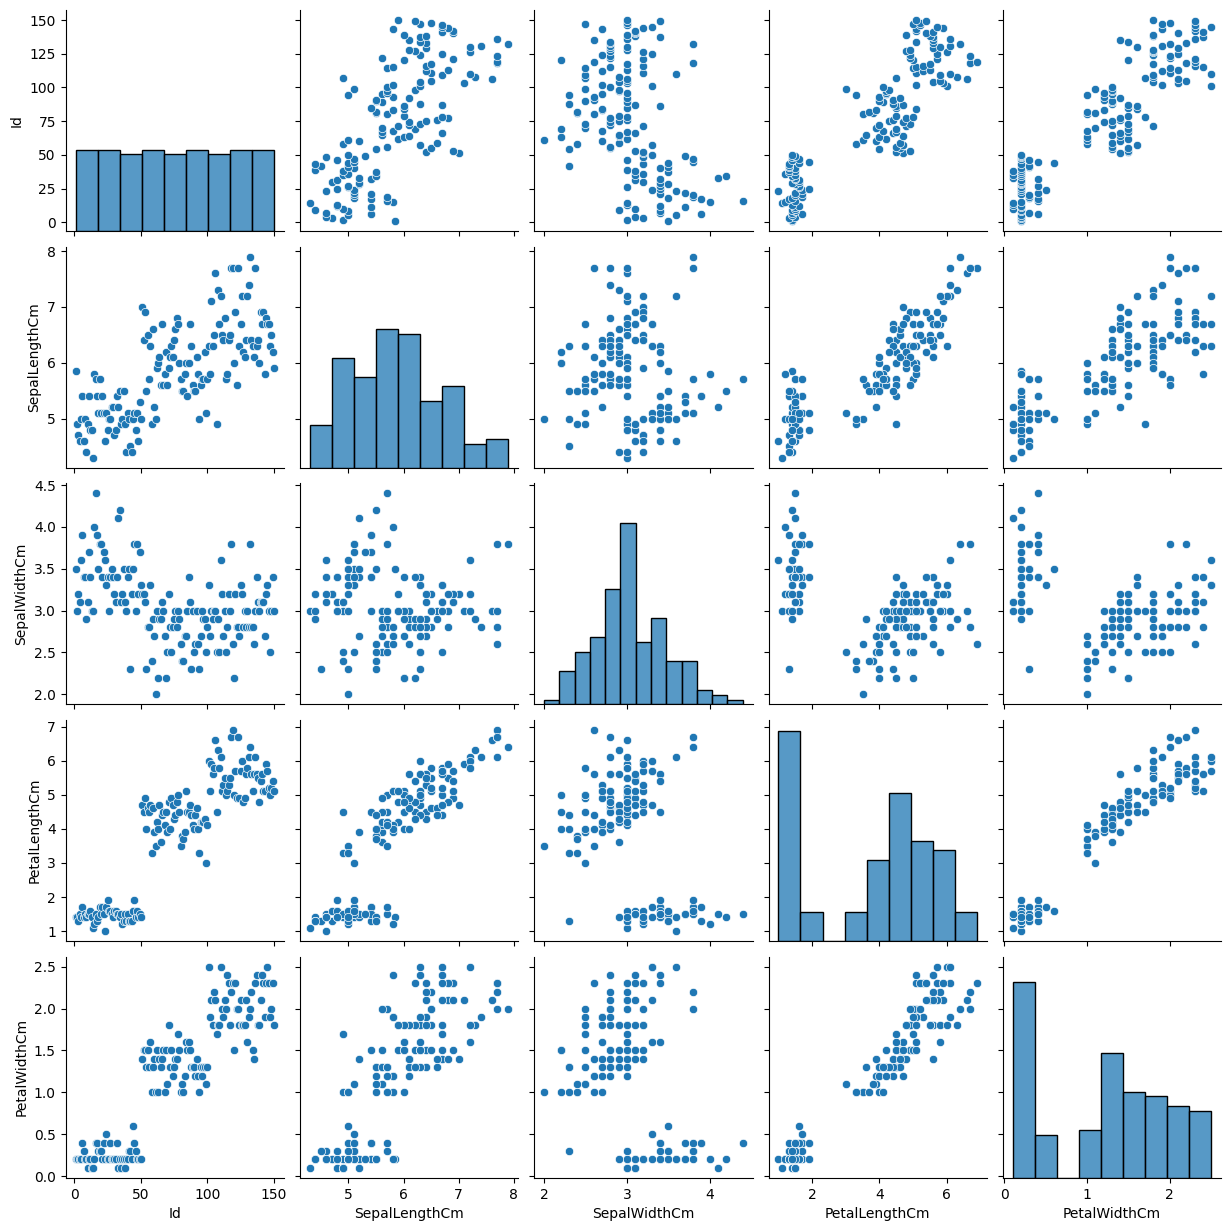

In [17]:
sns.pairplot(df)

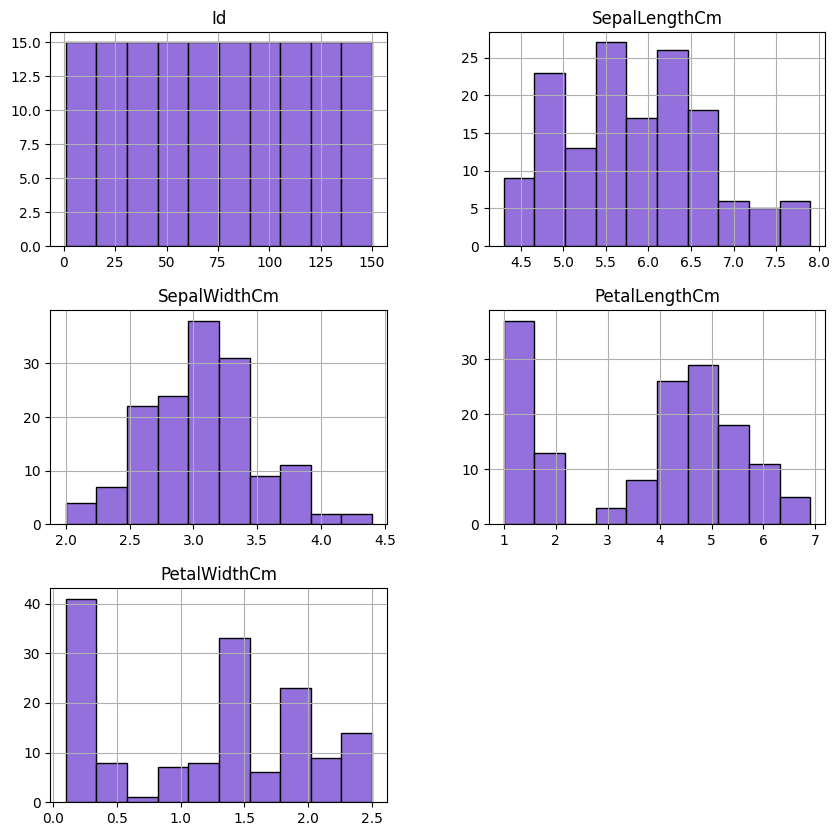

In [18]:
df.hist(color= 'mediumpurple' ,edgecolor='black',figsize=(10,10))
plt.show()

In [19]:
df.drop('Id', axis=1, inplace=True)

## Machine Learning

In [20]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [21]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.848322,3.5,1.4,0.2,Iris-setosa
1,4.900000,3.0,1.4,0.2,Iris-setosa
2,4.700000,3.2,1.3,0.2,Iris-setosa
3,4.600000,3.1,1.5,0.2,Iris-setosa
4,5.000000,3.6,1.4,0.2,Iris-setosa


In [22]:
X = df.drop('Species', axis=1)   #input
y = df['Species']      #output

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

### <font color="blue"><b>Logistic Regression</b></font>

In [23]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print(accuracy_score(y_test, y_pred))   #y_test >>> y_act

0.9333333333333333


In [16]:
from sklearn.metrics import precision_score, recall_score, classification_report

In [24]:
precision = precision_score(y_test, y_pred, average='micro')
precision

0.9333333333333333

In [25]:
recall = recall_score(y_test, y_pred, average='micro')
recall

0.9333333333333333

In [26]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[15,  0,  0],
       [ 0, 14,  1],
       [ 0,  2, 13]], dtype=int64)

In [27]:
42/45

0.9333333333333333

In [28]:
y_test.shape

(45,)

In [30]:
import pickle
# Save trained model
with open("iris_model.pkl", "wb") as file:
    pickle.dump(logreg, file)

print("Model saved successfully!")

Model saved successfully!


In [32]:
# Load the saved model
model = pickle.load(open("iris_model.pkl", "rb"))

# Take user input
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

# Convert input into array format
# Create a DataFrame with the correct column names to avoid the UserWarning
features_df = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]],
                           columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

# Predict species using the DataFrame
prediction = model.predict(features_df)

# The prediction directly contains the species name, so no need to index the 'species' list
print("Predicted Species:", prediction[0])

Enter Sepal Length:  5.848322
Enter Sepal Width:  3.5
Enter Petal Length:  1.4
Enter Petal Width:  0.2


Predicted Species: Iris-setosa
